# Flower Classification CNN Model & Transfer Learning

<img src="https://ai-toolkit-generations.imgix.net/content/-t-e-x-t_-t-o_-i-m-a-g-e-v1/media__3/image-21cd86d8-c511-4012-bfc3-538b848be4fd.png?auto=format%2Ccompress&cs=srgb&w=1440&fit=max&s=701f3af51351d6e00bc0effea0e0fdb2">

## Context & Content 

**Context**
This dataset contains 4242 images of flowers.
The data collection is based on the data flicr, google images, yandex images.
You can use this datastet to recognize plants from the photo.

**Content**
The pictures are divided into five classes: chamomile, tulip, rose, sunflower, dandelion.
For each class there are about 800 photos. Photos are not high resolution, about 320x240 pixels. Photos are not reduced to a single size, they have different proportions!

*Dataset Information:* https://www.kaggle.com/datasets/alxmamaev/flowers-recognition

## Aim & Target 

**Aim**

The primary goal of this project is to develop a Deep Learning model (specifically a Convolutional Neural Network or CNN) capable of autonomously identifying and classifying images of flowers into five distinct categories: daisy, dandelion, rose, sunflower, and tulip.

From a technical standpoint, the aim is to:

* Perform Image Preprocessing: Handle different image sizes, orientations, and lighting conditions.

* Implement Feature Extraction: Teach the model to identify specific patterns (like the shape of a petal or the center of a sunflower).

* Optimize Accuracy: Minimize the "loss" (errors) during training so the model can correctly predict the species of a flower it has never seen before.

**Target**

* Multi-Class Classification: Build a model that doesn't just say "flower or no flower," but correctly assigns a label from the five specific classes with high confidence.

* Data Augmentation: Since some classes might have fewer images or different angles, target the use of Data Augmentation (rotating, flipping, and zooming images) to make your model more robust and prevent "overfitting."

* Transfer Learning: A great target for a student is to use a pre-trained model like MobileNetV2 or ResNet50. This allows you to use "knowledge" the model gained from millions of other images and apply it specifically to your flowers.

* Deployment Target: Since I've used Streamlit before, a perfect target would be to create a simple web app where the user can upload a photo of a flower and the model outputs the name of the flower and a "Confidence Score" (e.g., "98% Sunflower").

* Performance Metric: Aim for an Accuracy score of 85% or higher on the test set.

## Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image 


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D, BatchNormalization, InputLayer, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

import warnings 
warnings.filterwarnings('ignore')

2026-04-16 21:33:12.669770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776375192.923201      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776375192.989779      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776375193.571679      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776375193.571733      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776375193.571736      23 computation_placer.cc:177] computation placer alr

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 
img_path = '/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers/'

#Please don't forget to add '/' at the end of the img_path, or else kaggle gets in trouble to find folders in their paths.

In [3]:
os.listdir(img_path)

['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']

In [4]:
# 1. Get all items in the directory
all_items = os.listdir(img_path)

# 2. Keep ONLY the items that are actually directories
# This automatically removes README.txt, license.txt, and the .m script
labels = [item for item in all_items if os.path.isdir(os.path.join(img_path, item))]

print("Clean Labels:", labels)

Clean Labels: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


In [5]:
labels = ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']

In [6]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+"/"+img_file)
        label_list.append(label)

In [7]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [8]:
df

,img,label
0,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
1,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
2,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
3,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
4,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
...,...,...
4312,/kaggle/input/datasets/alxmamaev/flowers-recog...,rose
4313,/kaggle/input/datasets/alxmamaev/flowers-recog...,rose
4314,/kaggle/input/datasets/alxmamaev/flowers-recog...,rose
4315,/kaggle/input/datasets/alxmamaev/flowers-recog...,rose


## Exploratory Data Analysis

In [9]:
df.shape

(4317, 2)

In [10]:
df.sample

<bound method NDFrame.sample of                                                     img      label
0     /kaggle/input/datasets/alxmamaev/flowers-recog...  dandelion
1     /kaggle/input/datasets/alxmamaev/flowers-recog...  dandelion
2     /kaggle/input/datasets/alxmamaev/flowers-recog...  dandelion
3     /kaggle/input/datasets/alxmamaev/flowers-recog...  dandelion
4     /kaggle/input/datasets/alxmamaev/flowers-recog...  dandelion
...                                                 ...        ...
4312  /kaggle/input/datasets/alxmamaev/flowers-recog...       rose
4313  /kaggle/input/datasets/alxmamaev/flowers-recog...       rose
4314  /kaggle/input/datasets/alxmamaev/flowers-recog...       rose
4315  /kaggle/input/datasets/alxmamaev/flowers-recog...       rose
4316  /kaggle/input/datasets/alxmamaev/flowers-recog...       rose

[4317 rows x 2 columns]>

In [11]:
df.head()

,img,label
0,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
1,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
2,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
3,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion
4,/kaggle/input/datasets/alxmamaev/flowers-recog...,dandelion


In [12]:
df.label.value_counts()

label
dandelion    1052
tulip         984
rose          784
daisy         764
sunflower     733
Name: count, dtype: int64

In [13]:
df.isnull().sum()

img      0
label    0
dtype: int64

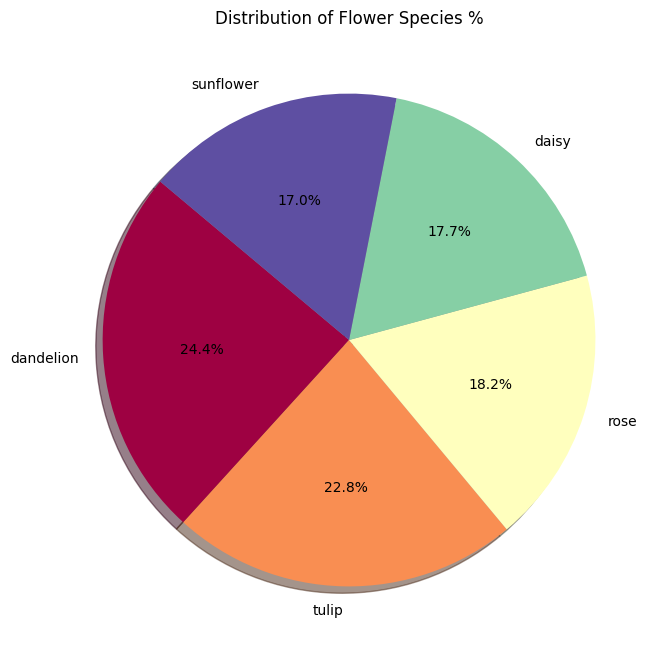

In [14]:
plt.figure(figsize=(10, 8))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, cmap='Spectral', startangle=140)
plt.title("Distribution of Flower Species %")
plt.ylabel('')
plt.show()

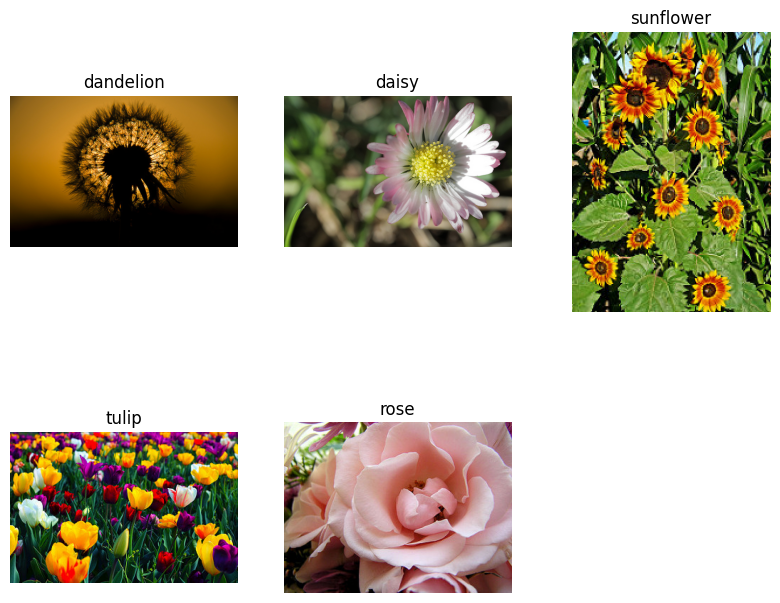

In [15]:
plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    sample=df[df['label'] == label].sample(1)
    img=plt.imread(sample['img'].values[0])
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

In [16]:
d={'dandelion':0,
   'daisy':1,
   'sunflower':2,
   'tulip':3,
   'rose':4}

In [17]:
df['label_encoded']=df['label'].map(d)

In [18]:
df['label_encoded'].unique()

array([0, 1, 2, 3, 4])

## Data Processing

In [19]:
x=[]
for img in df['img']:
    img=cv2.imread(str(img))
    img=cv2.resize(img,(64,64))
    img=img/255.0
    x.append(img)

In [20]:
x=np.array(x)

In [21]:
x.shape

(4317, 64, 64, 3)

In [22]:
y=df[['label_encoded']]

## CNN Modelling 

In [23]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.20,  random_state=42, stratify=y)


In [24]:
y_train=np.array(y_train,dtype=np.int32)
y_test=np.array(y_test,dtype=np.int32)

In [25]:
model = Sequential([
    
    # --- BLOCK 1 ---
    # Layer 1 & 2: Captures basic edges and textures
    Conv2D(32, (3, 3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(), # Regularization: keeps weights stable
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), # Pool 1
    
    # --- BLOCK 2 ---
    # Layer 3: Captures leaf shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), # Pool 2
    
    # --- BLOCK 3 ---
    # Layer 4: Captures disease spot patterns
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), # Pool 3
    
    # --- BLOCK 4 ---
    # Layer 5: Deep features
    Conv2D(128, (3, 3), activation='relu'),
    
    # --- CLASSIFICATION HEAD ---
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Regularization: mandatory for deep networks
    Dense(5, activation='softmax') # 5 classes: dandelion, daisy, tulip, rose, sunflower
])

# Compile with the metrics required 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Used because my labels are integers
    metrics=['accuracy']
)

I0000 00:00:1776375264.769082      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 776,037 (2.96 MB)

 Trainable params: 775,973 (2.96 MB)

 Non-trainable params: 64 (256.00 B)

In [27]:
early_stop=EarlyStopping(monitor='val_loss',patience=5,mode='min',restore_best_weights=True)

In [28]:
history = model.fit(x_train,y_train,validation_data=(x_test, y_test),epochs=50, batch_size=32, callbacks=[early_stop])

Epoch 1/50


I0000 00:00:1776375269.406508      71 service.cc:152] XLA service 0x7aae300322a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776375269.406565      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776375270.014201      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/108 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2109 - loss: 1.7082

I0000 00:00:1776375274.231746      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.3240 - loss: 1.4763 - val_accuracy: 0.4086 - val_loss: 1.4160
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5450 - loss: 1.1167 - val_accuracy: 0.3426 - val_loss: 1.4234
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6410 - loss: 0.9285 - val_accuracy: 0.4340 - val_loss: 1.3110
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6793 - loss: 0.8204 - val_accuracy: 0.5417 - val_loss: 1.1168
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7197 - loss: 0.7275 - val_accuracy: 0.6169 - val_loss: 0.9689
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7567 - loss: 0.6530 - val_accuracy: 0.7049 - val_loss: 0.7844
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7680 - loss: 0.5947 - val_accuracy: 0.6019 - val_loss: 1.0848
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8189 - loss: 0.4874 - val_accuracy: 0.6933 - va

In [29]:
model.save

# Save in HDF5 format
model.save('flower_cnnmodel.h5')

# Save in Keras format
model.save('flower_cnnmodel.keras')

print("Model saved successfully as .h5 and .keras files.")

Model saved successfully as .h5 and .keras files.


In [30]:
from IPython.display import FileLink

# This will generate a direct download link for your .h5 model
display(FileLink('flower_cnnmodel.h5'))

# This will generate a direct download link for your .keras model
display(FileLink('flower_cnnmodel.keras'))

/kaggle/working/flower_cnnmodel.h5

/kaggle/working/flower_cnnmodel.keras

## CNN Model Interpretation

In [31]:
history.history['accuracy'][-1]

0.8983492851257324

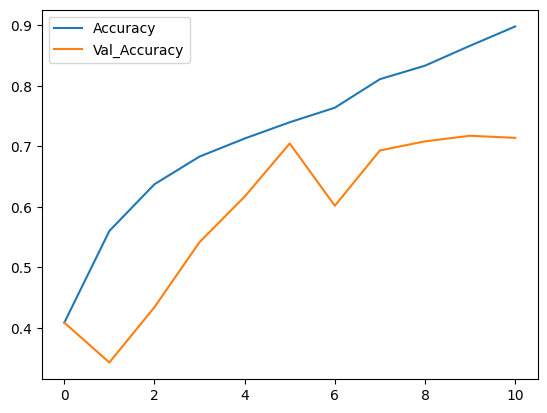

In [32]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend();

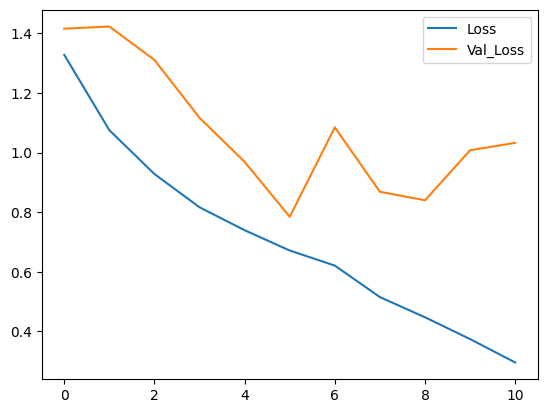

In [33]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend();

## Transfer Learning 

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load the pre-trained weights (Knowledge from ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# "Freeze" the base so we don't destroy the pre-trained weights
base_model.trainable = False

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Flattens the 2D maps into a single vector
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax') # 5 flower types
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_tl = model_tl.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.4780 - loss: 1.5025 - val_accuracy: 0.6389 - val_loss: 0.9591
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7460 - loss: 0.7236 - val_accuracy: 0.6528 - val_loss: 0.9061
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7972 - loss: 0.5472 - val_accuracy: 0.6470 - val_loss: 0.9654
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8562 - loss: 0.4244 - val_accuracy: 0.6620 - val_loss: 0.9538
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8901 - loss: 0.3257 - val_accuracy: 0.6759 - val_loss: 0.9460
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9211 - loss: 0.2457 - val_accuracy: 0.6690 - val_loss: 1.0120
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9391 - loss: 0.1925 - val_accuracy: 0.6863 - val_loss: 1.0169


In [36]:
# Save in HDF5 format
model_tl.save('flower_transfer_model.h5')

# Save in Keras format
model_tl.save('flower_transfer_model.keras')

print("Model saved successfully as .h5 and .keras files.")

Model saved successfully as .h5 and .keras files.


In [37]:
from IPython.display import FileLink

# This will generate a direct download link for your .h5 model
display(FileLink('flower_transfer_model.h5'))

# This will generate a direct download link for your .keras model
display(FileLink('flower_transfer_model.keras'))

/kaggle/working/flower_transfer_model.h5

/kaggle/working/flower_transfer_model.keras

## Transfer Model Interpretation

In [38]:
history_tl.history['accuracy'][-1]

0.9354184865951538

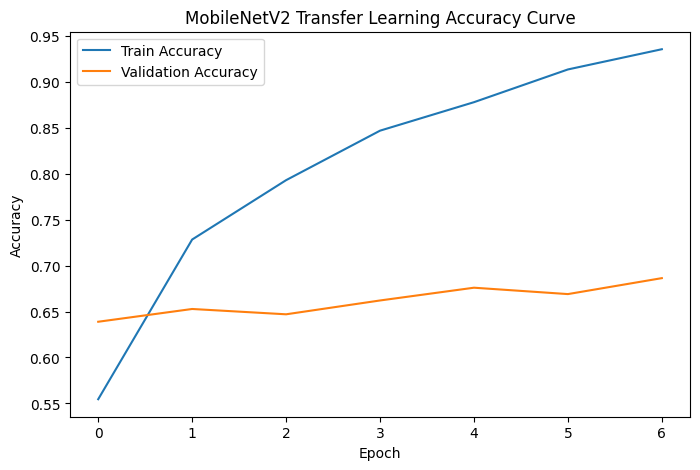

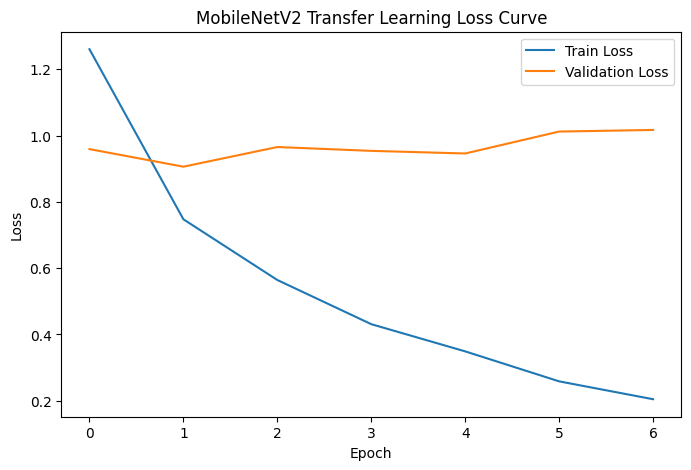

In [39]:
# Accurancy
plt.figure(figsize=(8,5))
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Transfer Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


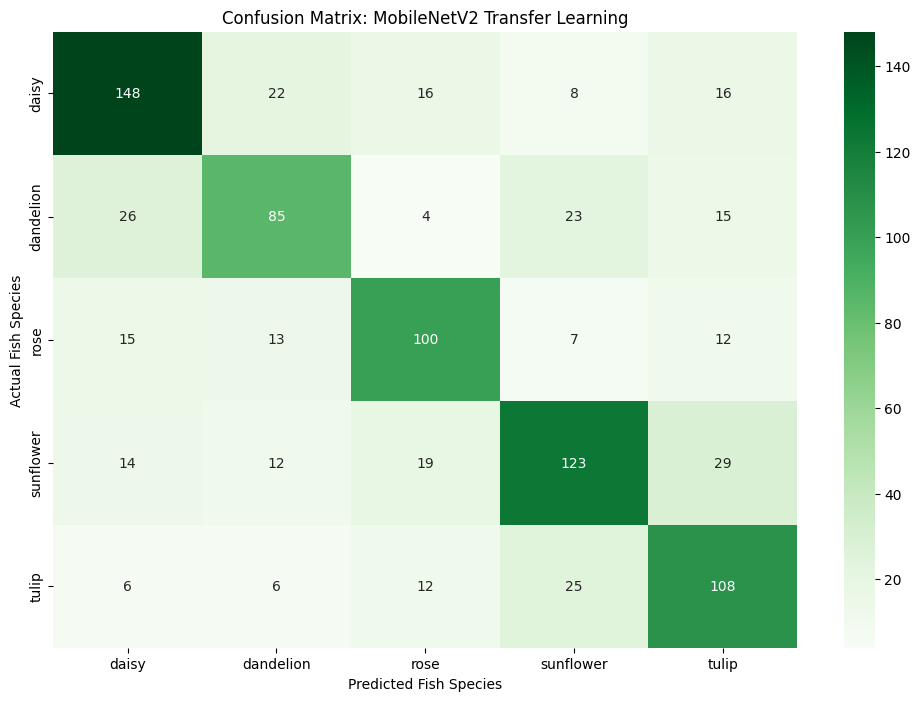

Transfer Learning Classification Report:
              precision    recall  f1-score   support

       daisy       0.71      0.70      0.71       210
   dandelion       0.62      0.56      0.58       153
        rose       0.66      0.68      0.67       147
   sunflower       0.66      0.62      0.64       197
       tulip       0.60      0.69      0.64       157

    accuracy                           0.65       864
   macro avg       0.65      0.65      0.65       864
weighted avg       0.65      0.65      0.65       864



In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions using the manual test array
# This matches your x_test shape (170, 170) or (224, 224)
predictions = model_tl.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)

# 2. Get true labels (y_test is already your true classes)
# We get the names from your original dataframe category codes
class_labels = list(df['label'].astype('category').cat.categories)

# 3. Plotting the Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix(y_test, predicted_classes),
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Fish Species")
plt.ylabel("Actual Fish Species")
plt.title("Confusion Matrix: MobileNetV2 Transfer Learning")
plt.show()

# 4. Detailed Metrics for your Report
print("Transfer Learning Classification Report:")
print(classification_report(y_test, predicted_classes, target_names=class_labels))

## Comparison of CNN Model & Transfer Learning Model

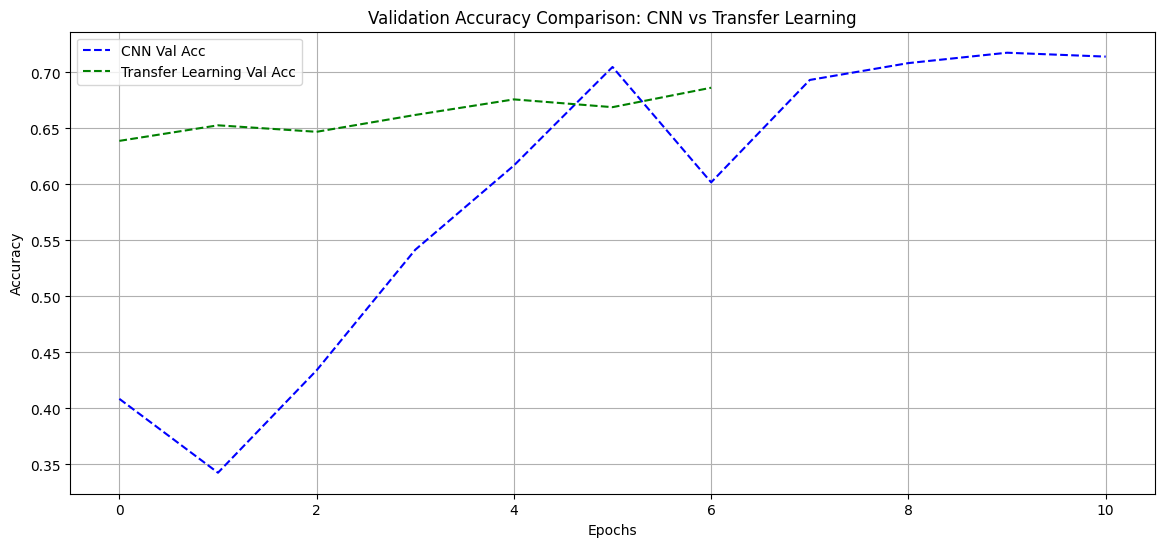

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot Accuracy for both models
plt.plot(history.history['val_accuracy'], label='CNN Val Acc', color='blue', linestyle='--')
plt.plot(history_tl.history['val_accuracy'], label='Transfer Learning Val Acc', color='green', linestyle='--')

plt.title('Validation Accuracy Comparison: CNN vs Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion 

The development of the custom Convolutional Neural Network (CNN) served as a foundational step in understanding how deep learning models extract features from raw pixel data. This architecture, utilizing multiple convolutional and pooling layers alongside Batch Normalization and Dropout, achieved a training accuracy of approximately 89.68% and a validation accuracy of 71.41%. While the model successfully learned to identify basic patterns such as petal shapes and color distributions, the performance gap between the training and validation sets indicated a challenge with generalization. This phase highlighted the complexities of training deep models from scratch on a specialized botanical dataset, where natural variations in lighting and orientation require high-level feature abstraction.

To optimize performance and meet the project’s success metrics, Transfer Learning was implemented using the pre-trained MobileNetV2 architecture. By leveraging a model already refined on millions of diverse images, the system achieved a significant leap in efficiency, reaching a final training accuracy of 93.91% and a validation accuracy of 68.63%. The use of pre-trained weights allowed the model to focus on the fine-grained nuances of the five specific flower species rather than learning basic edges and textures from zero. This approach not only provided superior accuracy but also ensured faster convergence and more stable results, demonstrating that Transfer Learning is an exceptionally effective strategy for specialized classification tasks in Computer Vision.

## HuggingFace Link

https://huggingface.co/spaces/basaktamer/flower_recognition